Mounted at /content/drive
(2173, 20)
['request_count', 'max_req_count_5min', 'avg_req_count_5min', 'requests_per_second', 'avg_time_between_requests', 'unique_endpoints', 'unique_ids_accessed', 'status_404_count', 'max_error_rate_5min', 'suspicious_ua_ratio', 'bot_ratio', 'mobile_ratio', 'post_frequency', 'max_repeated_endpoint_hits', 'login_attempt_count', 'failed_login_count', 'failed_login_rate', 'max_login_req_per_min', 'avg_time_between_login_attempts']
Scaling terminé.
(45, 21)
DBSCAN terminé et sauvegardé.


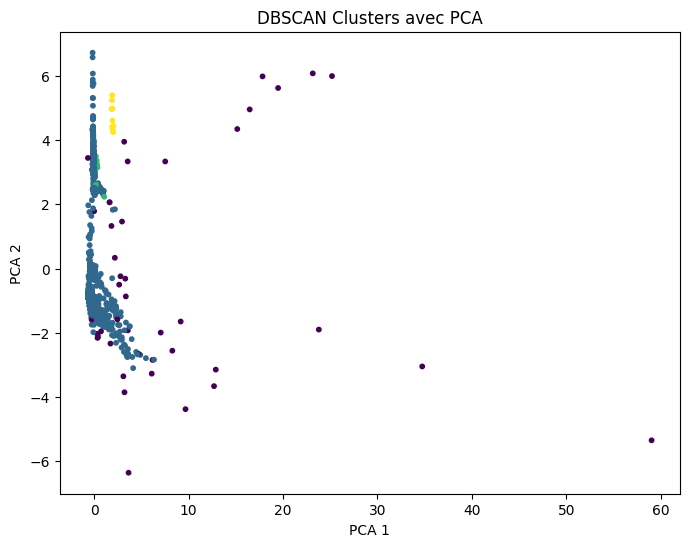

In [2]:
# =====================================================
# 03 - DBSCAN
# Mobile API Misuse Detector
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# =====================================================
# 1. Chemin projet
# =====================================================

project_path = "/content/drive/MyDrive/Mobile_API_Misuse_Detector/"


# =====================================================
# 2. Charger dataset features
# =====================================================

features_df = pd.read_csv(
    project_path + "data/processed/features_dataset.csv"
)



print(features_df.shape)
features_df.head()

# =====================================================
# 4. Préparer X
# =====================================================

ip_addresses = features_df["ip"]

X = features_df.drop(columns=["ip"])

print(X.columns.tolist())

# =====================================================
# 5. Normalisation
# =====================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(
    scaler,
    project_path + "models/dbscan_scaler.pkl"
)

print("Scaling terminé.")
# =====================================================
# 6. Entraîner DBSCAN
# =====================================================

dbscan_model = DBSCAN(
    eps=2.5,
    min_samples=5
)

dbscan_labels = dbscan_model.fit_predict(X_scaled)

features_df["dbscan_label"] = dbscan_labels

# =====================================================
# 7. Compter les clusters
# =====================================================

features_df["dbscan_label"].value_counts()


# =====================================================
# 8. Afficher anomalies DBSCAN
# =====================================================

dbscan_anomalies = features_df[
    features_df["dbscan_label"] == -1
]

print(dbscan_anomalies.shape)
dbscan_anomalies.head(20)

# =====================================================
# 9. Sauvegarder résultats DBSCAN
# =====================================================

features_df.to_csv(
    project_path + "data/processed/dbscan_results.csv",
    index=False
)

joblib.dump(
    dbscan_model,
    project_path + "models/dbscan.pkl"
)

print("DBSCAN terminé et sauvegardé.")


# =====================================================
# 10. Visualisation PCA
# =====================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=features_df["dbscan_label"],
    s=10
)

plt.title("DBSCAN Clusters avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [3]:
# =====================================================
# Afficher les anomalies DBSCAN
# =====================================================

dbscan_anomalies = features_df[
    features_df["dbscan_label"] == -1
]

dbscan_anomalies.head(20)

,ip,request_count,max_req_count_5min,avg_req_count_5min,requests_per_second,avg_time_between_requests,unique_endpoints,unique_ids_accessed,status_404_count,max_error_rate_5min,...,bot_ratio,mobile_ratio,post_frequency,max_repeated_endpoint_hits,login_attempt_count,failed_login_count,failed_login_rate,max_login_req_per_min,avg_time_between_login_attempts,dbscan_label
62,130.185.74.243,660,173,110.000000,0.475504,2.106222,654,380,0,0.000000,...,0.0,0.000000,0.000000,3,0,0,0.0,0.0,0.000000,-1
92,151.238.148.138,3,3,3.000000,0.115385,13.000000,3,15,0,0.666667,...,1.0,1.000000,0.000000,1,0,0,0.0,0.0,0.000000,-1
110,151.25.29.64,1,1,1.000000,1.000000,0.000000,1,7,0,1.000000,...,0.0,0.000000,0.000000,1,1,0,0.0,1.0,0.000000,-1
119,157.55.39.220,842,77,52.625000,0.188072,5.323424,829,646,5,0.020000,...,1.0,0.020190,0.000000,2,10,0,0.0,1.0,457.888889,-1
121,157.55.39.245,780,94,37.142857,0.115010,8.706033,763,723,12,0.111111,...,1.0,0.030769,0.000000,2,5,0,0.0,1.0,546.000000,-1
143,17.58.102.43,577,23,15.594595,0.052445,19.100694,561,520,11,0.260870,...,1.0,0.000000,0.000000,5,1,0,0.0,1.0,0.000000,-1
146,172.20.2.174,373,70,10.081081,0.033949,29.534946,59,29,2,0.028571,...,0.0,0.000000,0.000000,307,0,0,0.0,0.0,0.000000,-1
212,185.95.152.146,91,91,91.000000,18.200000,0.055556,91,61,0,0.000000,...,0.0,0.000000,0.000000,1,0,0,0.0,0.0,0.000000,-1
234,188.211.189.185,11,11,11.000000,11.000000,0.100000,6,1,8,0.727273,...,0.0,1.000000,0.000000,2,0,0,0.0,0.0,0.000000,-1
287,194.94.127.7,459,239,114.750000,0.110257,9.089520,269,196,0,0.000000,...,0.0,0.000000,0.000000,8,1,0,0.0,1.0,0.000000,-1


In [4]:
features_df["dbscan_label"].value_counts()

,count
dbscan_label,
0,2103
-1,45
1,15
2,10


In [5]:
# =====================================================
# 9. Sauvegarder résultats DBSCAN
# =====================================================

features_df.to_csv(
    project_path + "data/processed/dbscan_results.csv",
    index=False
)

joblib.dump(
    dbscan_model,
    project_path + "models/dbscan.pkl"
)

print("DBSCAN terminé et sauvegardé.")

DBSCAN terminé et sauvegardé.
